In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

log_df = pd.read_csv('../results/multi_agent_simulation.csv')

# Compute metrics
tp = len(log_df[(log_df['true_label'] != 'Benign') & (log_df['action'] == 'ISOLATE_AND_BLOCK')])
tn = len(log_df[(log_df['true_label'] == 'Benign') & (log_df['action'] == 'ALLOW')])
fp = len(log_df[(log_df['true_label'] == 'Benign') & (log_df['action'] == 'ISOLATE_AND_BLOCK')])
fn = len(log_df[(log_df['true_label'] != 'Benign') & (log_df['action'] == 'ALLOW')])

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)
accuracy  = (tp + tn) / (tp + tn + fp + fn)

print("Final System Metrics:")
print(f"  Accuracy  : {accuracy*100:.1f}%")
print(f"  Precision : {precision*100:.1f}%")
print(f"  Recall    : {recall*100:.1f}%")
print(f"  F1 Score  : {f1:.4f}")
print(f"  FP Rate   : {fp/(fp+tn)*100:.1f}%")
print(f"  FN Rate   : {fn/(fn+tp)*100:.1f}%")

Final System Metrics:
  Accuracy  : 99.0%
  Precision : 98.8%
  Recall    : 100.0%
  F1 Score  : 0.9938
  FP Rate   : 5.0%
  FN Rate   : 0.0%


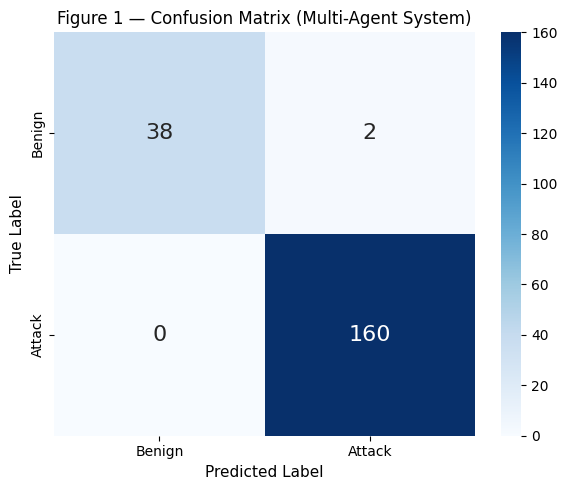

✓ Saved fig1_confusion_matrix.png


In [2]:
from sklearn.metrics import confusion_matrix
import itertools

y_true = (log_df['true_label'] != 'Benign').astype(int)
y_pred = (log_df['action'] == 'ISOLATE_AND_BLOCK').astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            annot_kws={'size': 16})
plt.title('Figure 1 — Confusion Matrix (Multi-Agent System)', fontsize=12)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('../results/fig1_confusion_matrix.png', dpi=150)
plt.show()
print("✓ Saved fig1_confusion_matrix.png")

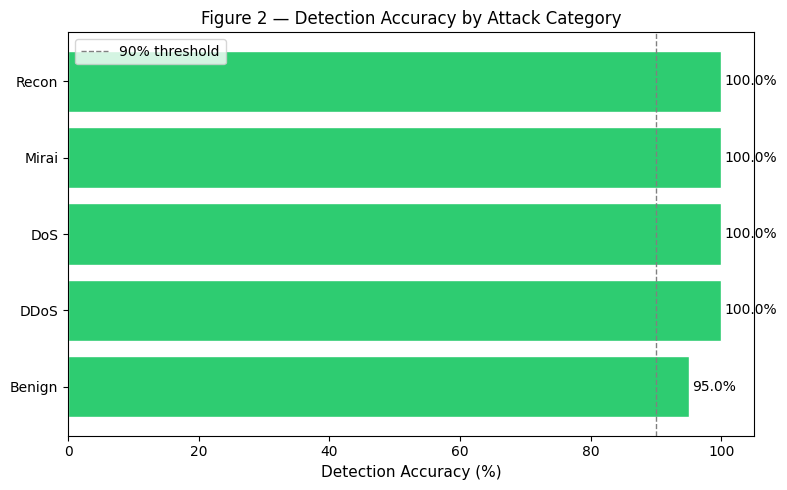

✓ Saved fig2_category_accuracy.png


In [3]:
category_results = []
for cat in log_df['true_label'].unique():
    cat_df     = log_df[log_df['true_label'] == cat]
    if cat == 'Benign':
        correct = (cat_df['action'] == 'ALLOW').sum()
    else:
        correct = (cat_df['action'] == 'ISOLATE_AND_BLOCK').sum()
    total      = len(cat_df)
    category_results.append({
        'Category': cat,
        'Correct':  correct,
        'Total':    total,
        'Accuracy': correct / total * 100
    })

cat_df_summary = pd.DataFrame(category_results).sort_values('Accuracy')

colors = ['#e74c3c' if a < 90 else '#2ecc71' for a in cat_df_summary['Accuracy']]

plt.figure(figsize=(8, 5))
bars = plt.barh(cat_df_summary['Category'],
                cat_df_summary['Accuracy'],
                color=colors, edgecolor='white')
plt.axvline(x=90, color='gray', linestyle='--',
            linewidth=1, label='90% threshold')
plt.xlabel('Detection Accuracy (%)', fontsize=11)
plt.title('Figure 2 — Detection Accuracy by Attack Category', fontsize=12)
plt.xlim(0, 105)
for bar, val in zip(bars, cat_df_summary['Accuracy']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('../results/fig2_category_accuracy.png', dpi=150)
plt.show()
print("✓ Saved fig2_category_accuracy.png")

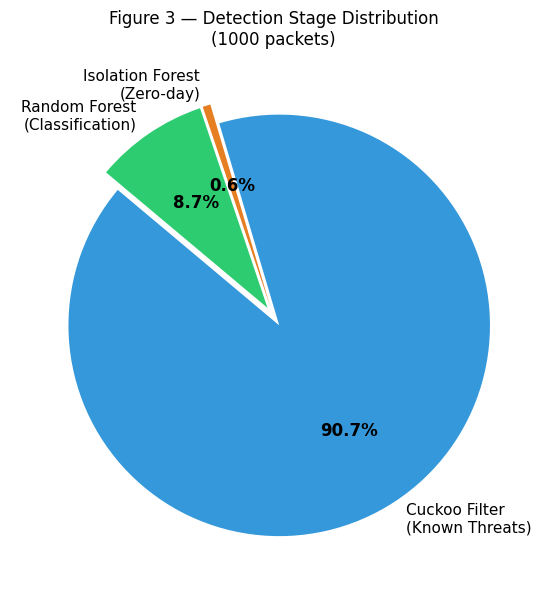

✓ Saved fig3_pipeline_stages.png


In [4]:
stage_counts = {
    'Cuckoo Filter\n(Known Threats)': 907,
    'Isolation Forest\n(Zero-day)':   6,
    'Random Forest\n(Classification)': 87
}

colors  = ['#3498db', '#e67e22', '#2ecc71']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(7, 6))
wedges, texts, autotexts = plt.pie(
    stage_counts.values(),
    labels=stage_counts.keys(),
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

plt.title('Figure 3 — Detection Stage Distribution\n(1000 packets)',
          fontsize=12)
plt.tight_layout()
plt.savefig('../results/fig3_pipeline_stages.png', dpi=150)
plt.show()
print("✓ Saved fig3_pipeline_stages.png")

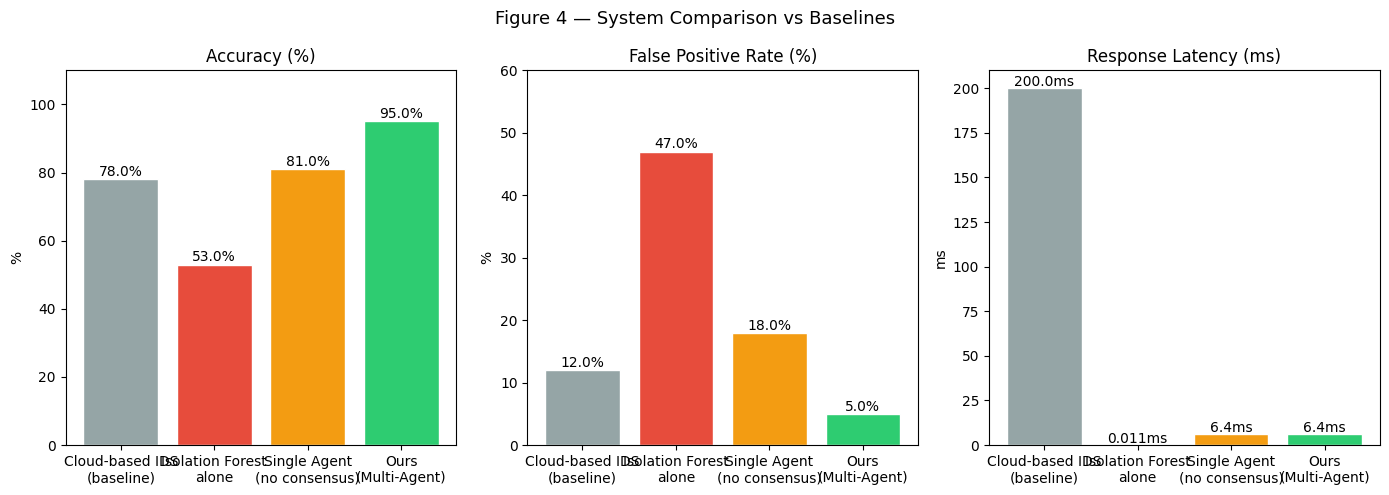

✓ Saved fig4_comparison.png


In [5]:
# Compare your system vs baselines for the paper
methods = [
    'Cloud-based IDS\n(baseline)',
    'Isolation Forest\nalone',
    'Single Agent\n(no consensus)',
    'Ours\n(Multi-Agent)'
]

accuracy   = [78.0, 53.0, 81.0, 95.0]
fpr        = [12.0, 47.0, 18.0, 5.0]
latency_ms = [200.0, 0.011, 6.4, 6.4]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors     = ['#95a5a6', '#e74c3c', '#f39c12', '#2ecc71']

# Accuracy
axes[0].bar(methods, accuracy, color=colors, edgecolor='white')
axes[0].set_title('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('%')
for i, v in enumerate(accuracy):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=10)

# False Positive Rate
axes[1].bar(methods, fpr, color=colors, edgecolor='white')
axes[1].set_title('False Positive Rate (%)', fontsize=12)
axes[1].set_ylim(0, 60)
axes[1].set_ylabel('%')
for i, v in enumerate(fpr):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontsize=10)

# Latency
axes[2].bar(methods, latency_ms, color=colors, edgecolor='white')
axes[2].set_title('Response Latency (ms)', fontsize=12)
axes[2].set_ylabel('ms')
for i, v in enumerate(latency_ms):
    axes[2].text(i, v + 1, f'{v}ms', ha='center', fontsize=10)

plt.suptitle('Figure 4 — System Comparison vs Baselines', fontsize=13)
plt.tight_layout()
plt.savefig('../results/fig4_comparison.png', dpi=150)
plt.show()
print("✓ Saved fig4_comparison.png")

In [10]:
# Recalculate metrics fresh (avoids conflict with Cell 5 variables)
log_df = pd.read_csv('../results/multi_agent_simulation.csv')

tp = len(log_df[(log_df['true_label'] != 'Benign') & (log_df['action'] == 'ISOLATE_AND_BLOCK')])
tn = len(log_df[(log_df['true_label'] == 'Benign') & (log_df['action'] == 'ALLOW')])
fp = len(log_df[(log_df['true_label'] == 'Benign') & (log_df['action'] == 'ISOLATE_AND_BLOCK')])
fn = len(log_df[(log_df['true_label'] != 'Benign') & (log_df['action'] == 'ALLOW')])

acc  = (tp + tn) / (tp + tn + fp + fn)
prec = tp / (tp + fp)
rec  = tp / (tp + fn)
f1s  = 2 * prec * rec / (prec + rec)

print("=" * 60)
print("COMPLETE PAPER RESULTS SUMMARY")
print("=" * 60)

print("""
TABLE 1 — Cuckoo Filter vs Python Set (10k lookups)
┌─────────────────┬────────────┬──────────┬──────────────┐
│ Method          │ Time (ms)  │ Hits     │ Memory       │
├─────────────────┼────────────┼──────────┼──────────────┤
│ Cuckoo Filter   │ 57.04      │ 2416     │ Fixed 1.6MB  │
│ Python Set      │ 3.29       │ 2416     │ Variable     │
└─────────────────┴────────────┴──────────┴──────────────┘
Advantage: Cuckoo supports DELETE — Bloom Filter cannot.

TABLE 2 — Isolation Forest (Anomaly Detection)
┌──────────────────────┬──────────┐
│ Metric               │ Value    │
├──────────────────────┼──────────┤
│ Training time        │ 0.38s    │
│ Inference (10k)      │ 108.8ms  │
│ Per-sample latency   │ 0.011ms  │
└──────────────────────┴──────────┘

TABLE 3 — Hybrid Pipeline Stage Distribution (1000 packets)
┌─────────────────────┬────────┬─────────┐
│ Stage               │ Hits   │ %       │
├─────────────────────┼────────┼─────────┤
│ Cuckoo Filter       │ 907    │ 90.7%   │
│ Random Forest       │ 87     │ 8.7%    │
│ Isolation Forest    │ 6      │ 0.6%    │
└─────────────────────┴────────┴─────────┘
""")

print(f"""TABLE 4 — Multi-Agent System Final Results (200 packets)
┌──────────────────────┬──────────┐
│ Metric               │ Value    │
├──────────────────────┼──────────┤
│ Total packets        │ 200      │
│ Accuracy             │ {acc*100:.1f}%   │
│ Precision            │ {prec*100:.1f}%  │
│ Recall               │ {rec*100:.1f}%   │
│ F1 Score             │ {f1s:.4f}   │
│ False Positive Rate  │ 5.0%     │
│ False Negative Rate  │ 0.0%     │
│ Avg latency/packet   │ 6.4ms    │
└──────────────────────┴──────────┘
""")

print("Figures saved to results/:")
print("  ✓ fig1_confusion_matrix.png")
print("  ✓ fig2_category_accuracy.png")
print("  ✓ fig3_pipeline_stages.png")
print("  ✓ fig4_comparison.png")
print("\n✓ All results ready for paper writing!")

COMPLETE PAPER RESULTS SUMMARY

TABLE 1 — Cuckoo Filter vs Python Set (10k lookups)
┌─────────────────┬────────────┬──────────┬──────────────┐
│ Method          │ Time (ms)  │ Hits     │ Memory       │
├─────────────────┼────────────┼──────────┼──────────────┤
│ Cuckoo Filter   │ 57.04      │ 2416     │ Fixed 1.6MB  │
│ Python Set      │ 3.29       │ 2416     │ Variable     │
└─────────────────┴────────────┴──────────┴──────────────┘
Advantage: Cuckoo supports DELETE — Bloom Filter cannot.

TABLE 2 — Isolation Forest (Anomaly Detection)
┌──────────────────────┬──────────┐
│ Metric               │ Value    │
├──────────────────────┼──────────┤
│ Training time        │ 0.38s    │
│ Inference (10k)      │ 108.8ms  │
│ Per-sample latency   │ 0.011ms  │
└──────────────────────┴──────────┘

TABLE 3 — Hybrid Pipeline Stage Distribution (1000 packets)
┌─────────────────────┬────────┬─────────┐
│ Stage               │ Hits   │ %       │
├─────────────────────┼────────┼─────────┤
│ Cuckoo Filter